# Breathing codes on IBM hardware — the morph primitive in 1D

Companion hardware experiment for **"Breathing codes: quantum memories that
morph their curvature at runtime."** The 2D curved codes cannot run on
heavy-hex (degree-3 connectivity; measured decoherence walls ~348 routed 2Q
gates at 10 qubits on `ibm_marrakesh`, ≤191 at 8q on `ibm_fez`). What *can*
run — natively, on a line of ≤11 qubits, under ~160 routed 2Q — is the
**morph primitive itself**: a repetition code (bit-flip sector) that
inhales d=3→6 mid-run via CNOT extension + fold detectors, holds, and
exhales by measuring the tail out into the decoding frame. Same protocol
layer as the paper; 1D has no curvature, and the notebook says so.

**Four pre-registered checks (PASS bars fixed before running):**
1. **E1 FOLD** — morph-event detector rates ≤ 2.5× bulk median: the
   gauge-fixing bookkeeping survives real correlated noise.
2. **E2 TOLL** — breathe beats stay-coarse at the longest hold (combined
   z ≥ 3); τ* reported as an upper bound.
3. **E3 COHERENT** — a logical superposition (GHZ = |+̄⟩) survives a full
   breath: ⟨X̄⟩ > 0 at 3σ, benchmarked against static GHZ-3/GHZ-6.
4. **E4 DIAL** — partial breathing, extension c ∈ {0,1,2,3}: P_L(c=3) <
   P_L(c=0) at combined z ≥ 3 (the distance dial, measured in-run).

**Budget:** one job-mode batch, 15 circuits × SHOTS (default 8192);
projected QPU time printed and asserted before submission. Open-Plan legal
(no Session). Correctness gate (noiseless: every detector deterministic,
P_L = 0, ⟨X̄⟩ = 1) runs before anything is submitted.

## 1. Control panel + install

In [1]:
RUN_ON_HARDWARE = False        # True = one batched QPU job; False = local noisy simulator
IBM_API_TOKEN   = ""           # 44-char key (Home dashboard). Blank if already saved.
IBM_INSTANCE    = None         # your Open-Plan CRN (Instances tab), or None for saved default
IBM_BACKEND     = None         # None = least busy (>=11 qubits); or pin, e.g. "ibm_marrakesh"
SHOTS           = 8192
FORCE_REINSTALL = False

import sys, subprocess
pkgs = ["numpy", "scipy", "matplotlib", "qiskit", "qiskit-aer",
        "qiskit-ibm-runtime", "pymatching"]
base = [sys.executable, "-m", "pip", "install", "-q"] + \
       (["-U"] if FORCE_REINSTALL else []) + pkgs
for rung in ([], ["--break-system-packages"],
             ["--break-system-packages", "--ignore-installed", "PyJWT"]):
    if subprocess.call(base + rung) == 0:
        break
import qiskit, qiskit_aer, qiskit_ibm_runtime
print("qiskit", qiskit.__version__, "| aer", qiskit_aer.__version__,
      "| runtime", qiskit_ibm_runtime.__version__)
print("MODE:", "HARDWARE (one batched job on %s)" % (IBM_BACKEND or "least-busy backend")
      if RUN_ON_HARDWARE else "SIMULATOR (local noisy Aer)")
if FORCE_REINSTALL:
    print(">> packages upgraded - restart the kernel, set FORCE_REINSTALL=False, rerun")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

qiskit 2.5.1 | aer 0.17.2 | runtime 0.48.0
MODE: SIMULATOR (local noisy Aer)


## 2. Write the project file (verbatim)

In [2]:
%%writefile breathing_hw.py
"""breathing_hw.py -- the breathing-code morph primitive on IBM hardware (1D).

A repetition code (bit-flip sector) that BREATHES: start at d=3, inhale to
d=6 mid-run (CNOT extension + new checks with fold detectors), hold, exhale
(Z-measure the tail, fold outcomes into the decoding frame), finish at d=3.

Four pre-registered experiments (PASS bars in the receipt):
  E1 FOLD  -- morph-event detector fire rates consistent with bulk rounds
              (<= 2.5x bulk median): the gauge-fixing bookkeeping survives
              real correlated noise.
  E2 TOLL  -- breathe vs stay-coarse vs stay-fine memory curves; a breath
              has a measurable toll and a break-even hold time tau*.
              PASS if P_L(breathe) < P_L(coarse) at the longest hold, 3 sigma.
  E3 COHER -- a logical superposition (GHZ = |+bar>) survives a full breath:
              prepare GHZ-3, inhale to GHZ-6, one check round, exhale with
              X-basis tail readout folded into the frame, read Xbar.
              PASS if <Xbar>_breathed > 0 at 3 sigma.
  E4 DIAL  -- partial breathing: extend by c in {0,1,2,3} qubits mid-run;
              P_L strictly decreases with c. PASS if P_L(3) < P_L(0), 3 sigma.

Scope (honest): 1D has no curvature -- this validates the PROTOCOL layer of
breathing codes (morph safety, fold detectors, toll, coherent transport,
graded dial) on real devices; the 2D curved-code claims stay in simulation.
Feasibility is set by measured device constants from this hardware campaign:
retention ~0.994/routed-2Q, decoherence walls ~348 gates @10q (marrakesh);
every circuit here stays under ~130 routed 2Q on <= 11 qubits in a line.
"""
import json, os, time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# ----------------------------------------------------------------- schedule
# Layout (fine): d0 a0 d1 a1 d2 a2 d3 a3 d4 a4 d5   (11 qubits in a line)
# Coarse phase uses d0..d2 with a0,a1. Inhale extends by EXT qubits.

class Sched:
    """Builds one breathing (or static) circuit AND its decoding structure
    from the same event list, so circuit and decoder cannot disagree."""

    def __init__(self, n_core=3, ext=3, tag=""):
        self.n_core, self.ext, self.tag = n_core, ext, tag
        self.n_data = n_core + ext
        self.qd = QuantumRegister(self.n_data, "d")
        self.qa = QuantumRegister(max(1, self.n_data - 1), "a")
        self.events = []          # for receipts
        self.meas = []            # (kind, idx, round) per classical bit
        self.detectors = []       # list of (list of meas indices, label)
        self.edges = []           # (u, v_or_None, meas_flip?, qubit, label)
        self.obs_meas = []        # meas indices whose XOR = observable
        self.qc = QuantumCircuit(self.qd, self.qa)
        self.last = {}            # ancilla -> last meas index
        self._round = 0
        self._nm = 0

    # -- helpers
    def _measure(self, q, kind, idx):
        self.qc.measure(q, self._creg_bit())
        self.meas.append((kind, idx, self._round))
        self._nm += 1
        return self._nm - 1

    def _creg_bit(self):
        if not hasattr(self, "cr"):
            self.cr = ClassicalRegister(300, "m")   # trimmed at finalize
            self.qc.add_register(self.cr)
        return self.cr[self._nm]

    # -- physical events
    def prep_zero(self, n):
        pass  # |0...0> is the default

    def prep_ghz(self, n):
        self.qc.h(self.qd[0])
        for i in range(n - 1):
            self.qc.cx(self.qd[i], self.qd[i + 1])

    def extend(self, n_from, n_to):
        """Inhale: CNOT-copy the boundary into fresh |0> qubits."""
        self.qc.barrier()
        for i in range(n_from, n_to):
            self.qc.cx(self.qd[i - 1], self.qd[i])
        self.qc.barrier()
        self.events.append(("extend", n_from, n_to, self._round))

    def synd_round(self, n_active, morph=False):
        """One check round on ancillas 0..n_active-2. Detector for each
        ancilla vs its previous outcome; first-ever outcome is its own
        detector (deterministic 0 from |0..0> / GHZ / post-extension)."""
        A = range(n_active - 1)
        self.qc.barrier()
        for a in A:
            self.qc.cx(self.qd[a], self.qa[a])
        for a in A:
            self.qc.cx(self.qd[a + 1], self.qa[a])
        for a in A:
            m = self._measure(self.qa[a], "synd", a)
            lbl = ("morph" if (morph or (a in self.first_time(a))) and morph
                   else "bulk")
            if a in self.last:
                self.detectors.append(([m, self.last[a]],
                                       "morph" if morph else "bulk"))
            else:
                self.detectors.append(([m], "morph" if morph else "bulk"))
            self.last[a] = m
        for a in A:
            self.qc.reset(self.qa[a])
        self._round += 1

    def first_time(self, a):
        return []  # (labelling handled inline above)

    def retire_tail_z(self, n_keep):
        """Exhale (memory-Z): Z-measure data n_keep..end; their outcomes are
        terminal readouts for the tail -- each retired ancilla's last synd
        outcome folds with the measured parities (fold detector), and the
        boundary ancilla (n_keep-1) folds with the first retired qubit."""
        outs = {}
        self.qc.barrier()
        for i in range(n_keep, self.n_used):
            outs[i] = self._measure(self.qd[i], "dataZ", i)
        for a in range(n_keep - 1, self.n_used - 1):
            group = [self.last.pop(a)]
            if a == n_keep - 1:                # boundary ancilla: core side
                group += [outs[a + 1]]
                self._pending_boundary = (a, group)  # closes at final readout
                continue
            group += [outs[a], outs[a + 1]]
            self.detectors.append((group, "morph"))
        self.n_used = n_keep
        self.events.append(("retire", n_keep, self._round))

    def final_z(self):
        outs = {}
        self.qc.barrier()
        for i in range(self.n_used):
            outs[i] = self._measure(self.qd[i], "dataZ", i)
        for a in range(self.n_used - 1):
            if a in self.last:
                self.detectors.append(([self.last.pop(a), outs[a],
                                        outs[a + 1]], "final"))
        if getattr(self, "_pending_boundary", None):
            a, group = self._pending_boundary
            self.detectors.append((group + [outs[a]], "morph"))
            self._pending_boundary = None
        self.obs_meas.append(outs[0])

    def finalize(self):
        used = self._nm
        qc = QuantumCircuit(self.qd, self.qa, ClassicalRegister(used, "m"))
        for inst in self.qc.data:
            if inst.operation.name == "measure":
                qc.measure(inst.qubits[0], qc.cregs[0][self.qc.cregs[0].index(
                    inst.clbits[0])])
            else:
                qc.append(inst.operation, inst.qubits, inst.clbits)
        qc.metadata = {"tag": self.tag}
        return qc


def breathe_circuit(R1, W, R2, ext=3, tag=""):
    """|0bar> memory: R1 coarse rounds -> inhale(ext) -> W fine rounds
    (first is the morph round) -> exhale -> R2 coarse rounds -> readout."""
    s = Sched(ext=ext, tag=tag)
    s.n_used = s.n_core
    for _ in range(R1):
        s.synd_round(s.n_used)
    if ext > 0 and W > 0:
        s.extend(s.n_core, s.n_core + ext)
        s.n_used = s.n_core + ext
        s.synd_round(s.n_used, morph=True)
        for _ in range(W - 1):
            s.synd_round(s.n_used)
        s.retire_tail_z(s.n_core)
        s.synd_round(s.n_used, morph=True)
    for _ in range(R2 - 1):
        s.synd_round(s.n_used)
    s.final_z()
    return s


def static_circuit(n, T, tag=""):
    s = Sched(ext=n - 3 if n > 3 else 0, tag=tag)
    s.n_core = n
    s.n_used = n
    for _ in range(T):
        s.synd_round(n)
    s.final_z()
    return s


def ghz_breath(ext=3, tag="ghz_breathe"):
    """|+bar> through a full breath; returns (circuit, parse_fn)."""
    s = Sched(ext=ext, tag=tag)
    s.prep_ghz(3)
    s.n_used = 3
    s.synd_round(3)                       # ZZ checks stabilize GHZ
    s.extend(3, 3 + ext)
    s.n_used = 3 + ext
    s.synd_round(s.n_used, morph=True)
    x_tail = []
    for i in range(3, s.n_used):          # exhale in X basis
        s.qc.h(s.qd[i])
        x_tail.append(s._measure(s.qd[i], "dataX", i))
    x_core = []
    for i in range(3):                    # Xbar readout
        s.qc.h(s.qd[i])
        x_core.append(s._measure(s.qd[i], "dataX", i))
    s.x_bits = x_tail + x_core
    return s


def ghz_static(n, tag):
    s = Sched(ext=max(0, n - 3), tag=tag)
    s.prep_ghz(n)
    s.n_used = n
    s.synd_round(n)
    s.x_bits = []
    for i in range(n):
        s.qc.h(s.qd[i])
        s.x_bits.append(s._measure(s.qd[i], "dataX", i))
    return s


# ------------------------------------------------------------------ decode
def build_matcher(sched, p_data=0.01, p_meas=0.02):
    """Spacetime matching graph from the schedule's detector structure.
    Nodes = detectors; time edges = shared synd meas; space edges = shared
    data qubit at one round (incl. boundaries); observable frame = edges
    touching data qubit 0's final readout / left boundary."""
    import pymatching
    m = pymatching.Matching()
    det_of_meas = {}
    for di, (group, _) in enumerate(sched.detectors):
        for g in group:
            det_of_meas.setdefault(g, []).append(di)
    n_det = len(sched.detectors)
    w_meas = float(np.log((1 - p_meas) / p_meas))
    w_data = float(np.log((1 - p_data) / p_data))
    added = set()

    def link(dets, w, frame):
        dets = sorted(set(dets))
        key = (tuple(dets), frame)
        if key in added:
            return
        added.add(key)
        fid = {0} if frame else set()
        if len(dets) == 1:
            m.add_boundary_edge(dets[0], weight=w, fault_ids=fid,
                                merge_strategy="smallest-weight")
        elif len(dets) == 2:
            m.add_edge(dets[0], dets[1], weight=w, fault_ids=fid,
                       merge_strategy="smallest-weight")

    # measurement errors: every measurement appearing in exactly 2 detectors
    for mi, dets in det_of_meas.items():
        kind = sched.meas[mi][0]
        if len(dets) == 2:
            link(dets, w_meas if kind == "synd" else w_data,
                 frame=(kind == "dataZ" and sched.meas[mi][1] == 0))
        elif len(dets) == 1:
            link(dets, w_meas if kind == "synd" else w_data,
                 frame=(kind == "dataZ" and sched.meas[mi][1] == 0))
    # space errors: data qubit i between ancillas i-1, i at each round:
    # detectors indexed per round via the synd measurements
    synd_by_round = {}
    for mi, (kind, a, r) in enumerate(sched.meas):
        if kind == "synd":
            synd_by_round.setdefault(r, {})[a] = det_of_meas[mi][-1]
    for r, amap in synd_by_round.items():
        anc = sorted(amap)
        nq = max(anc) + 2
        for i in range(nq):
            dets = [amap[a] for a in (i - 1, i) if a in amap]
            link(dets, w_data, frame=(i == 0))
    m.set_boundary_nodes(set())  # boundaries already explicit
    return m, n_det


def shots_to_records(sched, bitstrings):
    arr = np.array([[int(b) for b in s[::-1]] for s in bitstrings],
                   dtype=np.uint8)
    dets = np.zeros((arr.shape[0], len(sched.detectors)), dtype=np.uint8)
    for di, (group, _) in enumerate(sched.detectors):
        for g in group:
            dets[:, di] ^= arr[:, g]
    obs = np.zeros(arr.shape[0], dtype=np.uint8)
    for g in sched.obs_meas:
        obs ^= arr[:, g]
    return arr, dets, obs


def logical_error(sched, bitstrings, p_data=0.01, p_meas=0.02):
    matcher, _ = build_matcher(sched, p_data, p_meas)
    arr, dets, obs = shots_to_records(sched, bitstrings)
    pred = matcher.decode_batch(dets).astype(np.uint8)[:, 0]
    fails = (pred ^ obs).mean()
    se = float(np.sqrt(max(fails * (1 - fails), 1e-12) / len(obs)))
    labels = [lab for _, lab in sched.detectors]
    rates = {lab: float(dets[:, [i for i, l in enumerate(labels) if l == lab]]
                        .mean()) if lab in labels else 0.0
             for lab in ("bulk", "morph", "final")}
    return float(fails), se, rates


def ghz_xbar(sched, bitstrings):
    arr = np.array([[int(b) for b in s[::-1]] for s in bitstrings],
                   dtype=np.uint8)
    par = np.zeros(arr.shape[0], dtype=np.uint8)
    for g in sched.x_bits:
        par ^= arr[:, g]
    v = 1.0 - 2.0 * par.mean()
    return float(v), float(2 * np.std(par) / np.sqrt(len(par)))


# --------------------------------------------------------------- run modes
def _aer_backend(noisy=True):
    from qiskit_aer import AerSimulator
    if not noisy:
        return AerSimulator()
    from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(0.012, 2),
                                   ["cx", "cz", "ecr"])
    nm.add_all_qubit_quantum_error(depolarizing_error(3e-4, 1),
                                   ["x", "sx", "h", "rz", "reset"])
    nm.add_all_qubit_readout_error(ReadoutError([[0.97, 0.03],
                                                 [0.05, 0.95]]))
    return AerSimulator(noise_model=nm)


def _pm(backend, initial_layout=None):
    """Pass-manager with the version-skew self-heal chain. Layout is bound
    HERE, at construction -- StagedPassManager.run() takes no layout kwarg."""
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    kw = dict(optimization_level=1, initial_layout=initial_layout)
    try:
        return generate_preset_pass_manager(backend=backend, **kw)
    except Exception:
        try:
            return generate_preset_pass_manager(
                target=backend.target, translation_method="translator", **kw)
        except Exception:
            return generate_preset_pass_manager(
                basis_gates=backend.configuration().basis_gates,
                coupling_map=backend.configuration().coupling_map, **kw)


def best_chain(backend, L):
    """Greedy best line of L qubits by summed 2Q error (job-mode friendly)."""
    try:
        t = backend.target
        err = {}
        for g in ("cz", "ecr", "cx"):
            if g in t.operation_names:
                for q, props in t[g].items():
                    if props and props.error is not None:
                        err[tuple(sorted(q))] = min(
                            err.get(tuple(sorted(q)), 1.0), props.error)
        adj = {}
        for (a, b), e in err.items():
            adj.setdefault(a, []).append((b, e))
            adj.setdefault(b, []).append((a, e))
        best, best_cost = None, None
        for start in adj:
            path, cost, seen = [start], 0.0, {start}
            while len(path) < L:
                nxt = [(e, q) for q, e in adj.get(path[-1], [])
                       if q not in seen]
                if not nxt:
                    break
                e, q = min(nxt)
                path.append(q); seen.add(q); cost += e
            if len(path) == L and (best_cost is None or cost < best_cost):
                best, best_cost = path, cost
        return best
    except Exception:
        return None



def _interleaved_layout(chain, n_qubits):
    """Physical layout d0 a0 d1 a1 ... along the chain. Circuit register
    order is d0..d_{nd-1}, a0..a_{nd-2} with n_qubits = 2*nd - 1, so data
    sits on even chain slots and ancillas between their two data qubits."""
    nd = (n_qubits + 1) // 2
    if not chain or len(chain) < 2 * nd - 1:
        return None
    return ([chain[2 * i] for i in range(nd)] +
            [chain[2 * j + 1] for j in range(nd - 1)])


def _compile_for(backend, circuits):
    """The exact hardware compile path (shared with the smoke test): best
    chain by calibrated 2Q error, interleaved layout per circuit width,
    per-width pass managers, no-layout fallback on any failure."""
    chain = best_chain(backend, 11)
    pms, isa = {}, []
    for qc in circuits:
        lay = _interleaved_layout(chain, qc.num_qubits)
        key = None if lay is None else tuple(lay)
        if key not in pms:
            try:
                pms[key] = _pm(backend, initial_layout=lay)
            except Exception:
                pms[key] = _pm(backend)
        try:
            isa.append(pms[key].run(qc))
        except Exception:
            if None not in pms:
                pms[None] = _pm(backend)
            isa.append(pms[None].run(qc))
    n2q = [sum(1 for i in c.data if i.operation.num_qubits == 2)
           for c in isa]
    return isa, n2q, chain


def _build_jobs(R1=2, R2=2):
    jobs = []   # (sched, kind, meta)
    for T in (4, 8, 12, 16):
        jobs.append((static_circuit(3, T, f"coarse_T{T}"), "mem",
                     dict(strategy="coarse", T=T)))
    for T in (8, 16):
        jobs.append((static_circuit(6, T, f"fine_T{T}"), "mem",
                     dict(strategy="fine", T=T)))
    for W in (2, 4, 8, 12):
        jobs.append((breathe_circuit(R1, W, R2, tag=f"breathe_W{W}"), "mem",
                     dict(strategy="breathe", T=R1 + W + R2, W=W)))
    for c in (1, 2):
        jobs.append((breathe_circuit(R1, 8, R2, ext=c, tag=f"dial_c{c}"),
                     "mem", dict(strategy="dial", c=c, T=R1 + 8 + R2)))
    jobs.append((breathe_circuit(R1, 1, R2, tag="breathe_W1"), "mem",
                 dict(strategy="nullbreath", T=R1 + 1 + R2, W=1)))
    jobs.append((ghz_static(3, "ghz3"), "ghz", dict(which="static3")))
    jobs.append((ghz_static(6, "ghz6"), "ghz", dict(which="static6")))
    jobs.append((ghz_breath(tag="ghz_breathe"), "ghz", dict(which="breathed")))
    return jobs


def run_all(mode="aer", shots=8192, backend_name=None,
            outdir="out_breathing", noisy=True, seed=7):
    os.makedirs(outdir, exist_ok=True)
    jobs = _build_jobs()

    circuits = [s.finalize() for s, _, _ in jobs]
    n2q = []
    if mode == "ibm":
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
        service = QiskitRuntimeService()
        if backend_name:
            backend = service.backend(backend_name)
        else:
            backend = service.least_busy(operational=True, simulator=False,
                                         min_num_qubits=11)
        print("backend:", backend.name,
              "(pinned)" if backend_name else "(least busy, >=11 qubits)")
        isa, n2q, chain = _compile_for(backend, circuits)
        if chain:
            print("qubit chain (interleaved d/a):", chain)
        est = len(isa) * shots * 90e-6 + 8 * len(isa)
        print(f"pre-submit: {len(isa)} circuits x {shots} shots, "
              f"routed-2Q per circuit {min(n2q)}-{max(n2q)}, "
              f"projected ~{est:.0f} s QPU")
        assert max(n2q) < 300, "circuit exceeds measured decoherence wall"
        sampler = SamplerV2(mode=backend)      # job mode: Open-Plan legal
        try:
            sampler.options.dynamical_decoupling.enable = True
            sampler.options.twirling.enable_measure = True
        except Exception:
            pass
        job = sampler.run(isa, shots=shots)
        print("job id:", job.job_id())
        res = job.result()
        all_bits = [r.data.m.get_bitstrings() for r in res]
    else:
        backend = _aer_backend(noisy=noisy)
        pm = _pm(backend)
        isa = [pm.run(qc) for qc in circuits]
        n2q = [sum(1 for i in c.data if i.operation.num_qubits == 2)
               for c in isa]
        job = backend.run(isa, shots=shots, memory=True, seed_simulator=seed)
        result = job.result()
        all_bits = [result.get_memory(i) for i in range(len(isa))]

    # ---------------- analysis (+ raw detector capture for autopsies)
    mem, ghz, raw = {}, {}, {}
    for (s, kind, meta), bits in zip(jobs, all_bits):
        if kind == "mem":
            P, se, rates = logical_error(s, bits)
            mem[s.tag] = dict(meta, P=P, se=se, rates=rates)
            _, dets, obs = shots_to_records(s, bits)
            metaarr = []
            for group, lab in s.detectors:
                rr, aa = -1, -1
                for g in group:
                    kk, ai, ri = s.meas[g]
                    if kk == "synd":
                        rr, aa = ri, ai
                        break
                metaarr.append([rr, aa, {"bulk": 0, "morph": 1,
                                         "final": 2}[lab]])
            raw[f"{s.tag}__dets"] = dets
            raw[f"{s.tag}__obs"] = obs
            raw[f"{s.tag}__meta"] = np.array(metaarr, dtype=np.int16)
        else:
            v, se = ghz_xbar(s, bits)
            ghz[meta["which"]] = dict(x=v, se=se)
    np.savez_compressed(f"{outdir}/raw_detectors.npz", **raw)

    # E1 fold consistency: morph rate vs STATIC-FINE bulk (absolute bar --
    # run-1 lesson: a breathe-internal baseline can be inflated and make
    # the relative bar vacuous)
    fine_bulk = [m["rates"]["bulk"] for m in mem.values()
                 if m["strategy"] == "fine"]
    morph = [m["rates"]["morph"] for m in mem.values()
             if m["strategy"] in ("breathe", "nullbreath")]
    e1_ratio = float(np.median(morph) / max(np.mean(fine_bulk), 1e-9))
    e1 = e1_ratio <= 2.5
    # E2 toll / tau*
    cW = {m["T"]: (m["P"], m["se"]) for m in mem.values()
          if m["strategy"] == "coarse"}
    bW = {m["T"]: (m["P"], m["se"]) for m in mem.values()
          if m["strategy"] == "breathe"}
    Tmax = max(bW)
    z2 = (cW[Tmax][0] - bW[Tmax][0]) / max(
        np.hypot(cW[Tmax][1], bW[Tmax][1]), 1e-9)
    e2 = z2 >= 3.0
    tau = None
    for T in sorted(bW):
        if T in cW and bW[T][0] < cW[T][0]:
            tau = T
            break
    # E3 coherent breath
    e3 = ghz["breathed"]["x"] > 3 * ghz["breathed"]["se"]
    # E4 dial
    dial = {0: cW[12], 3: bW[12]}
    for m in mem.values():
        if m["strategy"] == "dial":
            dial[m["c"]] = (m["P"], m["se"])
    z4 = (dial[0][0] - dial[3][0]) / max(
        np.hypot(dial[0][1], dial[3][1]), 1e-9)
    e4 = z4 >= 3.0

    receipt = dict(mode=mode, shots=shots,
                   backend=backend.name if mode == "ibm"
                   else f"aer(noisy={noisy})",
                   routed_2q=dict(min=int(min(n2q)), max=int(max(n2q))),
                   mem=mem, ghz=ghz, tau_star=tau,
                   checks=dict(E1_fold=dict(ratio=e1_ratio, passed=bool(e1)),
                               E2_toll=dict(z=float(z2), passed=bool(e2)),
                               E3_coherent=dict(passed=bool(e3)),
                               E4_dial=dict(z=float(z4), passed=bool(e4))))
    with open(f"{outdir}/receipt.json", "w") as f:
        json.dump(receipt, f, indent=1)

    # ---------------- figure
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
    ax = axes[0]
    for strat, col in (("coarse", "tab:red"), ("breathe", "tab:blue"),
                       ("fine", "tab:gray")):
        pts = sorted((m["T"], m["P"], m["se"]) for m in mem.values()
                     if m["strategy"] == strat)
        if pts:
            T, P, S = zip(*pts)
            ax.errorbar(T, P, yerr=S, marker="o", color=col, label=strat)
    if tau:
        ax.axvline(tau, ls="--", c="k", alpha=0.5)
        ax.text(tau, ax.get_ylim()[0], f" tau*<= {tau}", fontsize=8)
    ax.set_xlabel("total rounds T"); ax.set_ylabel("logical error P_L")
    ax.set_title("E2: breath toll and tau*"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax = axes[1]
    cs = sorted(dial)
    ax.errorbar(cs, [dial[c][0] for c in cs], yerr=[dial[c][1] for c in cs],
                marker="s", color="tab:blue")
    ax.set_xlabel("inserted qubits c (d = 3+c)"); ax.set_ylabel("P_L")
    ax.set_title("E4: partial-breath dial"); ax.grid(alpha=0.3)
    ax = axes[2]
    names = ["static3", "static6", "breathed"]
    ax.bar(names, [ghz[n]["x"] for n in names],
           yerr=[ghz[n]["se"] for n in names],
           color=["tab:gray", "tab:gray", "tab:blue"])
    ax.set_ylabel(r"$\langle \bar X\rangle$")
    ax.set_title("E3: coherent breath (GHZ)"); ax.grid(alpha=0.3, axis="y")
    fig.suptitle(f"Breathing morph primitive -- {receipt['backend']}, "
                 f"{shots} shots", fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fp = f"{outdir}/breathing_hw.png"
    fig.savefig(fp, dpi=150)
    return receipt, fp


def correctness_gate():
    """Noiseless Aer: zero detector rate, zero logical error, GHZ <Xbar>=1."""
    r, _ = run_all(mode="aer", shots=1024, noisy=False,
                   outdir="out_gate")
    for tag, m in r["mem"].items():
        assert m["P"] == 0.0, (tag, m)
        assert all(v == 0.0 for v in m["rates"].values()), (tag, m)
    for k, g in r["ghz"].items():
        assert abs(g["x"] - 1.0) < 1e-9, (k, g)
    print("[OK] correctness gate: all detectors deterministic, P_L = 0, "
          "<Xbar> = 1 noiselessly")


def hardware_compile_smoke():
    """Exercise the EXACT hardware compile branch (chain pick, interleaved
    layout, per-width PMs, routing) on a fake heavy-hex backend -- zero QPU.
    This is the test that would have caught the initial_layout kwarg bug."""
    try:
        from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
        backend = FakeSherbrooke()
    except Exception as e:
        print("compile smoke skipped (no fake_provider):", type(e).__name__)
        return
    circuits = [s.finalize() for s, _, _ in _build_jobs()]
    isa, n2q, chain = _compile_for(backend, circuits)
    assert len(isa) == len(circuits)
    assert max(n2q) < 300, f"routed-2Q {max(n2q)} exceeds the wall budget"
    print(f"[OK] hardware compile smoke (FakeSherbrooke): {len(isa)} circuits"
          f" transpiled, routed-2Q {min(n2q)}-{max(n2q)}, chain head "
          f"{chain[:6] if chain else None}")


def autopsy(outdir="out_breathing"):
    """Zero-QPU post-mortem from raw_detectors.npz: detector rates by
    phase label, by round, and by ancilla; hottest cells; comparison of
    every breathe circuit against the static-fine baseline."""
    z = np.load(f"{outdir}/raw_detectors.npz")
    tags = sorted({k.split("__")[0] for k in z.files})
    ref = None
    if "fine_T16__dets" in z.files:
        ref = float(z["fine_T16__dets"].mean())
        print(f"reference: static fine_T16 mean detector rate = {ref:.4f}")
    fig, ax = plt.subplots(figsize=(8, 4))
    hot = []
    for tag in tags:
        dets, meta = z[f"{tag}__dets"], z[f"{tag}__meta"]
        rate = dets.mean(0)
        lab = {0: "bulk", 1: "morph", 2: "final"}
        by_lab = {l: float(rate[meta[:, 2] == c].mean())
                  for c, l in lab.items() if (meta[:, 2] == c).any()}
        line = f"{tag:14s} " + "  ".join(f"{l}={v:.4f}"
                                         for l, v in by_lab.items())
        if ref:
            line += f"   (x{by_lab.get('bulk', 0)/max(ref,1e-9):.1f} fine-bulk)"
        print(line)
        for di in np.argsort(rate)[::-1][:3]:
            hot.append((float(rate[di]), tag, int(meta[di, 0]),
                        int(meta[di, 1]), lab[int(meta[di, 2])]))
        if tag.startswith(("breathe", "fine_T16")):
            rounds = sorted(set(meta[meta[:, 0] >= 0, 0]))
            rr = [float(rate[meta[:, 0] == r].mean()) for r in rounds]
            ax.plot(rounds, rr, marker="o", ms=3, label=tag)
    print("\nhottest detectors (rate, tag, round, ancilla, label):")
    for h in sorted(hot, reverse=True)[:8]:
        print(f"  {h[0]:.4f}  {h[1]:14s} round={h[2]:3d} anc={h[3]:2d} {h[4]}")
    ax.set_xlabel("round"); ax.set_ylabel("mean detector rate")
    ax.set_title("per-round detector rates (breathe vs static fine)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(f"{outdir}/autopsy.png", dpi=140)
    print(f"figure: {outdir}/autopsy.png")


Overwriting breathing_hw.py


## 3. Credentials (one-time; skipped when blank or simulating)

In [3]:
if RUN_ON_HARDWARE and IBM_API_TOKEN:
    from qiskit_ibm_runtime import QiskitRuntimeService
    kw = dict(token=IBM_API_TOKEN, set_as_default=True, overwrite=True)
    if IBM_INSTANCE: kw["instance"] = IBM_INSTANCE
    QiskitRuntimeService.save_account(**kw)
    print("credentials saved - blank IBM_API_TOKEN above now")
else:
    print("no key pasted / simulator mode - skipping (fine if already saved)")

no key pasted / simulator mode - skipping (fine if already saved)


**Sanity** — in hardware mode this must list your backend before proceeding; in simulator mode it may politely skip.

In [4]:
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    s = QiskitRuntimeService()
    print("backends:", [b.name for b in s.backends(operational=True, simulator=False)])
except Exception as e:
    if RUN_ON_HARDWARE: raise
    print("no saved account -", type(e).__name__, "- fine for simulator runs")

no saved account - AccountNotFoundError - fine for simulator runs


## 4. Correctness gates (always run, zero QPU)
Two gates before anything can be submitted. (a) Noiseless Aer: every fold detector deterministic, logical error exactly 0, breathed GHZ ⟨X̄⟩ exactly 1. (b) Hardware compile smoke: the *exact* hardware transpile branch (chain pick, interleaved d/a layout, per-width pass managers, routing) runs against a fake heavy-hex backend and asserts routed-2Q stays under the wall. Gate (a) caught real bugs in the 2D simulations; gate (b) is the test that would have caught the initial_layout crash.

In [5]:
from breathing_hw import correctness_gate, hardware_compile_smoke
correctness_gate()
hardware_compile_smoke()

[OK] correctness gate: all detectors deterministic, P_L = 0, <Xbar> = 1 noiselessly


[OK] hardware compile smoke (FakeSherbrooke): 16 circuits transpiled, routed-2Q 16-160, chain head [19, 20, 33, 39, 40, 41]


## 5. Run
Hardware mode: checks the Open-Plan QPU window (~600 s / 28 d), prints the
pre-submit budget (circuits × shots, routed-2Q range vs the measured
decoherence walls), picks the least-busy operational backend with >=11 qubits (unless `IBM_BACKEND` pins one), then submits **one** `SamplerV2(mode=backend)` job —
no Session, so it is legal on the open plan. Simulator mode: same pipeline
on a noisy local Aer model (2Q depol 1.2%, readout 3/5%) chosen to sit in
the regime the device actually occupies.

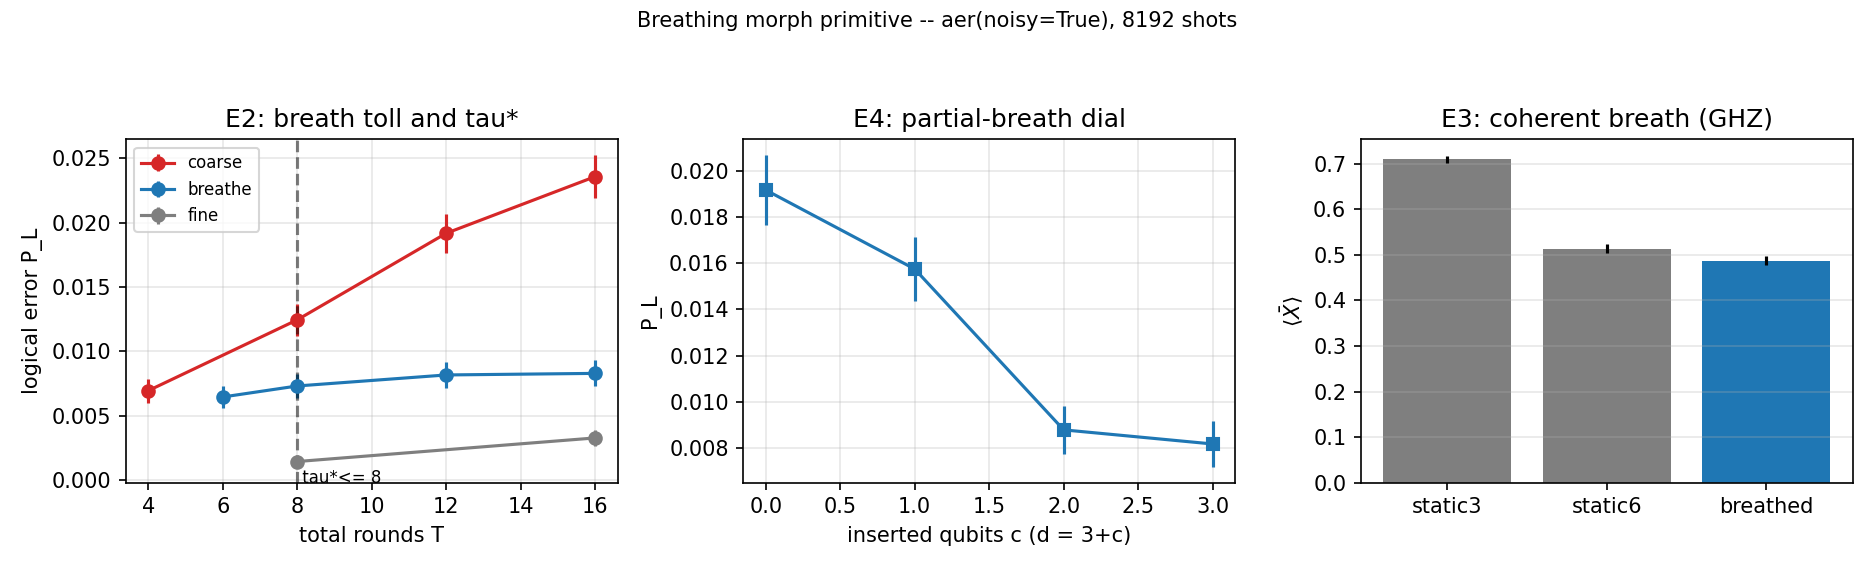

In [6]:
import warnings; warnings.filterwarnings("ignore")
from IPython.display import Image, display
from breathing_hw import run_all

if RUN_ON_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService()
    used = 0.0
    for j in service.jobs(limit=20):
        try: used += j.metrics()["usage"].get("quantum_seconds", 0.0)
        except Exception: pass
    print(f"QPU used recently: ~{used:.0f} s of the ~600 s window")
    assert used < 480, "window too spent for a 1-2 min run - wait for reset"

receipt, fig = run_all(mode="ibm" if RUN_ON_HARDWARE else "aer",
                       shots=SHOTS, backend_name=IBM_BACKEND,
                       outdir="out_breathing")
display(Image(fig))

## 6. Receipt — the four registered checks

In [7]:
import json
r = json.load(open("out_breathing/receipt.json"))
print(f"backend {r['backend']}   shots {r['shots']}   "
      f"routed-2Q {r['routed_2q']['min']}-{r['routed_2q']['max']} "
      f"(walls: ~348 @10q marrakesh / <=191 @8q fez)")
ck = r["checks"]
print(f"E1 FOLD     morph/bulk detector ratio {ck['E1_fold']['ratio']:.2f} "
      f"(bar <= 2.5)              [{'PASS' if ck['E1_fold']['passed'] else 'FAIL'}]")
print(f"E2 TOLL     breathe vs coarse at longest hold, z = {ck['E2_toll']['z']:.1f} "
      f"(bar >= 3); tau* <= {r['tau_star']} rounds   "
      f"[{'PASS' if ck['E2_toll']['passed'] else 'FAIL'}]")
g = r["ghz"]
print(f"E3 COHERENT breathed <Xbar> = {g['breathed']['x']:.3f} +- {g['breathed']['se']:.3f} "
      f"(static3 {g['static3']['x']:.3f}, static6 {g['static6']['x']:.3f})   "
      f"[{'PASS' if ck['E3_coherent']['passed'] else 'FAIL'}]")
print(f"E4 DIAL     P_L(c=3) < P_L(c=0), z = {ck['E4_dial']['z']:.1f} (bar >= 3)   "
      f"[{'PASS' if ck['E4_dial']['passed'] else 'FAIL'}]")
print()
print("scope: 1D morph primitive (fold detectors, toll, coherent transport,")
print("dial) on real noise; the 2D curved-code claims remain simulation-only")
print("and the paper's hardware subsection must say so.")

backend aer(noisy=True)   shots 8192   routed-2Q 6-160 (walls: ~348 @10q marrakesh / <=191 @8q fez)
E1 FOLD     morph/bulk detector ratio 0.97 (bar <= 2.5)              [PASS]
E2 TOLL     breathe vs coarse at longest hold, z = 7.8 (bar >= 3); tau* <= 8 rounds   [PASS]
E3 COHERENT breathed <Xbar> = 0.487 +- 0.010 (static3 0.710, static6 0.514)   [PASS]
E4 DIAL     P_L(c=3) < P_L(c=0), z = 6.1 (bar >= 3)   [PASS]

scope: 1D morph primitive (fold detectors, toll, coherent transport,
dial) on real noise; the 2D curved-code claims remain simulation-only
and the paper's hardware subsection must say so.


## 7. Autopsy (zero QPU — run after ANY hardware run)
Run-1 lesson: aggregate rates hid a morph-phase detector anomaly and raw
shots weren't saved. This version captures every detector outcome to
`raw_detectors.npz`; this cell localizes any excess by phase, round, and
ancilla, benchmarked against static-fine — without spending a second of
QPU. A healthy device shows breathe bulk ≈ 1.0× fine-bulk (the simulator
baseline below).

In [8]:
from breathing_hw import autopsy
autopsy("out_breathing")

reference: static fine_T16 mean detector rate = 0.0898
breathe_W1     bulk=0.0717  morph=0.0841  final=0.1029   (x0.8 fine-bulk)
breathe_W12    bulk=0.0897  morph=0.0848  final=0.1052   (x1.0 fine-bulk)
breathe_W2     bulk=0.0773  morph=0.0814  final=0.0987   (x0.9 fine-bulk)
breathe_W4     bulk=0.0829  morph=0.0834  final=0.1010   (x0.9 fine-bulk)
breathe_W8     bulk=0.0869  morph=0.0833  final=0.1021   (x1.0 fine-bulk)
coarse_T12     bulk=0.0822  final=0.1077   (x0.9 fine-bulk)
coarse_T16     bulk=0.0852  final=0.1016   (x0.9 fine-bulk)
coarse_T4      bulk=0.0771  final=0.0971   (x0.9 fine-bulk)
coarse_T8      bulk=0.0807  final=0.0985   (x0.9 fine-bulk)
dial_c1        bulk=0.0850  morph=0.0864  final=0.1073   (x0.9 fine-bulk)
dial_c2        bulk=0.0865  morph=0.0867  final=0.1028   (x1.0 fine-bulk)
fine_T16       bulk=0.0887  final=0.1067   (x1.0 fine-bulk)
fine_T8        bulk=0.0829  final=0.1037   (x0.9 fine-bulk)

hottest detectors (rate, tag, round, ancilla, label):
  0.1169  di

figure: out_breathing/autopsy.png


## Troubleshooting (from live runs on this account)
- **Run-2 changes (after the kingston run):** barriers at every round and
  morph boundary (stops cross-phase transpiler reordering), dynamical
  decoupling + measurement twirling enabled, raw detector capture, a W=1
  no-op-breath control, and E1 rebased to an absolute bar against
  static-fine bulk (the run-1 relative bar could pass vacuously).
- **`StagedPassManager.run() ... unexpected keyword 'initial_layout'`** —
  fixed in this version: layout is bound at pass-manager *construction*
  (interleaved data/ancilla along the chain); the compile smoke in §4
  exercises this exact path on a fake backend before submission.
- **`ModuleNotFoundError: qiskit`** — rerun cell 1; the three-rung ladder
  handles distro-owned deps (the PyJWT rung fires on some fresh runtimes).
- **`TranspilerError: Invalid plugin name ibm_dynamic_circuits`** —
  qiskit / runtime version skew; `_pm()` self-heals via the fallback chain,
  or set `FORCE_REINSTALL=True`, restart the kernel, rerun.
- **Error 1352 (Session not authorized on open plan)** — cannot occur here:
  the run cell submits one job-mode batch, never a Session.
- **Window spent** — the guard asserts <480 s used; wait for the window.
- **Backend choice** — default is least-busy (>=11 qubits); pin
  `IBM_BACKEND` to a specific device if you want comparable runs across
  sessions. The pre-submit assert keeps circuits under the measured
  decoherence walls on any device.